# Stochastic Gradient Descent

## Learning Objectives
- Understand why Batch Gradient Descent is expensive for large datasets and how SGD addresses it
- Derive the per-example gradient update rule from first principles
- Understand why the per-example gradient is an **unbiased estimator** of the full gradient
- Understand Taylor expansion as the mathematical justification for gradient descent
- Implement `train_sgd` and `predict_sgd` in NumPy

## Problem Statement

Given a training set of $m$ examples $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$, find parameters $\boldsymbol{\theta} \in \mathbb{R}^{n+1}$ that minimize the mean squared error cost:

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m} \sum_{i=1}^{m} \bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

---

### Why Not Batch Gradient Descent for Large Data?

BGD computes the full gradient over all $m$ examples at every step:

$\displaystyle \nabla_{\boldsymbol{\theta}} J = \frac{1}{m} X^\top (X\boldsymbol{\theta} - \mathbf{y})$

This costs $O(mn)$ per iteration — prohibitively slow when $m$ is in the millions.

| Property | Batch GD | Stochastic GD |
|---|---|---|
| Gradient computed over | All $m$ examples | 1 random example |
| Cost per update | $O(mn)$ | $O(n)$ |
| Path to minimum | Smooth | Noisy zigzag |
| Convergence | Stable | Oscillates near minimum |
| Best for | Small datasets | Large / streaming datasets |

---

### Core Idea

Approximate the full gradient with the gradient from a **single randomly chosen example** $(x^{(i)}, y^{(i)})$:

$\displaystyle \boldsymbol{\theta} := \boldsymbol{\theta} - \alpha \nabla_{\boldsymbol{\theta}} J^{(i)}(\boldsymbol{\theta})$

This works because $\nabla_{\boldsymbol{\theta}} J^{(i)}$ is an **unbiased estimator** of the full gradient — on average it points in the right direction.

---

### Taylor Expansion — Why Gradient Descent Works

For a smooth function $J$, the first-order Taylor expansion around $\boldsymbol{\theta}$ is:

$\displaystyle J(\boldsymbol{\theta} + \delta) \approx J(\boldsymbol{\theta}) + \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})^\top \delta$

Choosing $\delta = -\alpha \nabla_{\boldsymbol{\theta}} J$ gives:

$\displaystyle J(\boldsymbol{\theta} + \delta) \approx J(\boldsymbol{\theta}) - \alpha \|\nabla_{\boldsymbol{\theta}} J\|^2$

Since $\alpha \|\nabla_{\boldsymbol{\theta}} J\|^2 \geq 0$, each step is **guaranteed to decrease $J$** (for small enough $\alpha$). The same argument applies to SGD with the per-example gradient.

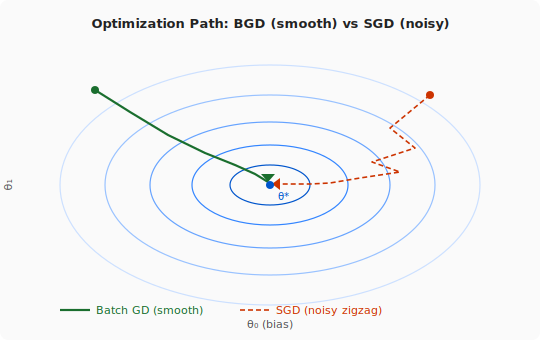

In [1]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="540" height="340" viewBox="0 0 540 340">
  <rect width="540" height="340" fill="#fafafa" rx="8"/>

  <text x="270" y="28" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">Optimization Path: BGD (smooth) vs SGD (noisy)</text>

  <ellipse cx="270" cy="185" rx="210" ry="120" fill="none" stroke="#cce0ff" stroke-width="1.2"/>
  <ellipse cx="270" cy="185" rx="165" ry="90"  fill="none" stroke="#99c2ff" stroke-width="1.2"/>
  <ellipse cx="270" cy="185" rx="120" ry="63"  fill="none" stroke="#66a3ff" stroke-width="1.2"/>
  <ellipse cx="270" cy="185" rx="78"  ry="40"  fill="none" stroke="#3385ff" stroke-width="1.2"/>
  <ellipse cx="270" cy="185" rx="40"  ry="20"  fill="none" stroke="#0055cc" stroke-width="1.2"/>

  <text x="270" y="328" text-anchor="middle" font-size="11" fill="#555">&#x03B8;&#x2080; (bias)</text>
  <text x="12"  y="185" text-anchor="middle" font-size="11" fill="#555" transform="rotate(-90,12,185)">&#x03B8;&#x2081;</text>

  <polyline points="95,90 130,112 168,135 205,153 235,165 255,174 268,182" fill="none" stroke="#1a6e2e" stroke-width="2.2" stroke-linejoin="round"/>
  <polygon points="268,182 261,174 275,174" fill="#1a6e2e"/>

  <polyline points="430,95 390,128 415,148 372,162 400,172 360,178 330,183 310,184 285,184 272,184"
            fill="none" stroke="#cc3300" stroke-width="1.6" stroke-dasharray="5,3" stroke-linejoin="round"/>
  <polygon points="272,184 280,178 280,190" fill="#cc3300"/>

  <circle cx="270" cy="185" r="4" fill="#0055cc"/>
  <text x="278" y="200" font-size="10" fill="#0055cc">&#x03B8;*</text>

  <circle cx="95"  cy="90"  r="4" fill="#1a6e2e"/>
  <circle cx="430" cy="95"  r="4" fill="#cc3300"/>

  <line x1="60"  y1="310" x2="90"  y2="310" stroke="#1a6e2e" stroke-width="2.2"/>
  <text x="96"  y="314" font-size="11" fill="#1a6e2e">Batch GD (smooth)</text>
  <line x1="240" y1="310" x2="270" y2="310" stroke="#cc3300" stroke-width="1.6" stroke-dasharray="5,3"/>
  <text x="276" y="314" font-size="11" fill="#cc3300">SGD (noisy zigzag)</text>
</svg>
"""

display(SVG(svg))

## Hypothesis Function

The hypothesis (prediction) function is identical to BGD — SGD changes *how we update* $\boldsymbol{\theta}$, not the model itself.

For a single example $x \in \mathbb{R}^{n+1}$ (with $x_0 = 1$ prepended):

$\displaystyle h_{\boldsymbol{\theta}}(x) = \boldsymbol{\theta}^\top x = \theta_0 x_0 + \theta_1 x_1 + \cdots + \theta_n x_n$

In vectorized form over the full design matrix $X \in \mathbb{R}^{m \times (n+1)}$:

$\displaystyle \hat{\mathbf{y}} = X\boldsymbol{\theta}$

where

$\displaystyle X = \begin{bmatrix} 1 & x_1^{(1)} & \cdots & x_n^{(1)} \\ 1 & x_1^{(2)} & \cdots & x_n^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & \cdots & x_n^{(m)} \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix}$

## Derivation

**High-level steps:**
1. Define the per-example cost $J^{(i)}$
2. Compute the partial derivative $\partial J^{(i)} / \partial \theta_j$
3. Apply the chain rule to expand the derivative
4. Substitute $\hat{y}^{(i)} = \boldsymbol{\theta}^\top x^{(i)}$ and simplify
5. Vectorize to the per-example gradient $\nabla_{\boldsymbol{\theta}} J^{(i)}$; show it is an unbiased estimator
6. Write the SGD update rule

---

**Step 1 — Per-example cost**

Drop the $\frac{1}{m}$ average; define the cost for a single example $(x^{(i)}, y^{(i)})$:

$\displaystyle J^{(i)}(\boldsymbol{\theta}) = \frac{1}{2}\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

---

**Step 2 — Partial derivative**

$\displaystyle \frac{\partial J^{(i)}}{\partial \theta_j} = \frac{\partial}{\partial \theta_j} \frac{1}{2}\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

---

**Step 3 — Chain rule**

$\displaystyle \frac{\partial J^{(i)}}{\partial \theta_j} = \bigl(\hat{y}^{(i)} - y^{(i)}\bigr) \cdot \frac{\partial \hat{y}^{(i)}}{\partial \theta_j}$

---

**Step 4 — Substitute $\hat{y}^{(i)} = \boldsymbol{\theta}^\top x^{(i)}$**

$\displaystyle \frac{\partial \hat{y}^{(i)}}{\partial \theta_j} = x_j^{(i)}$

Therefore:

$\displaystyle \frac{\partial J^{(i)}}{\partial \theta_j} = \bigl(\hat{y}^{(i)} - y^{(i)}\bigr)\, x_j^{(i)}$

---

**Step 5 — Vectorize; unbiased estimator**

Stack all $j$ components into a gradient vector:

$\displaystyle \nabla_{\boldsymbol{\theta}} J^{(i)} = \bigl(\hat{y}^{(i)} - y^{(i)}\bigr)\, x^{(i)}$

**Unbiased estimator property** — the expected value over a uniformly random example equals the full gradient:

$\displaystyle \mathbb{E}_i\!\left[\nabla_{\boldsymbol{\theta}} J^{(i)}\right] = \frac{1}{m}\sum_{i=1}^{m} \nabla_{\boldsymbol{\theta}} J^{(i)} = \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$

So on average, each per-example update steps in the correct direction.

---

**Step 6 — SGD update rule**

Replace the full-batch gradient with the per-example gradient:

$\displaystyle \boldsymbol{\theta} := \boldsymbol{\theta} - \alpha\,\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)\, x^{(i)}$

Cost per update: $O(n)$ — independent of $m$.

## Training Phase

**Step 1 — Prepare the design matrix**
Prepend a column of ones to $X$ to absorb the bias term $\theta_0$, giving $X \in \mathbb{R}^{m \times (n+1)}$.

**Step 2 — Initialize parameters**
Set $\boldsymbol{\theta} = \mathbf{0} \in \mathbb{R}^{n+1}$.

**Step 3 — For each epoch**
Shuffle the training examples to ensure the random order is different each pass. Shuffling removes ordering bias and improves convergence.

**Step 4 — For each example $(x^{(i)}, y^{(i)})$ in the shuffled order**
Compute the prediction:

$\displaystyle \hat{y}^{(i)} = \boldsymbol{\theta}^\top x^{(i)}$

**Step 5 — Compute the per-example gradient**

$\displaystyle \nabla_{\boldsymbol{\theta}} J^{(i)} = \bigl(\hat{y}^{(i)} - y^{(i)}\bigr)\, x^{(i)}$

**Step 6 — Update parameters**

$\displaystyle \boldsymbol{\theta} := \boldsymbol{\theta} - \alpha\,\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)\, x^{(i)}$

Repeat Steps 4–6 for every example in the epoch.

**Step 7 — Use the learned parameters**
The final $\boldsymbol{\theta}$ defines the trained model. Predict on new input $x$:

$\displaystyle \hat{y} = h_{\boldsymbol{\theta}}(x) = x^\top \boldsymbol{\theta}$

## Prediction Phase

**Step 1 — Prepare the input**
Prepend $x_0 = 1$ to each new example so the input matches the shape of $\boldsymbol{\theta}$.

**Step 2 — Apply the hypothesis function**

$\displaystyle \hat{\mathbf{y}} = X_{\text{new}}\,\boldsymbol{\theta}$

where $X_{\text{new}} \in \mathbb{R}^{p \times (n+1)}$ holds the $p$ new examples with the bias column prepended.

**Step 3 — Return predictions**
$\hat{\mathbf{y}} \in \mathbb{R}^p$ contains one predicted value per new example.

In [2]:
import numpy as np

def train_sgd(X, y, alpha=0.01, n_epochs=50):
    """
    Inputs
    ------
    X        : np.ndarray, shape (m, n+1)  — design matrix with bias column (x_0 = 1) prepended
    y        : np.ndarray, shape (m,)      — target values
    alpha    : float                       — learning rate (step size per update)
    n_epochs : int                         — number of full passes over the training set

    Output
    ------
    theta        : np.ndarray, shape (n+1,)  — learned parameter vector θ
    cost_history : list[float]               — cost J(θ) recorded after each epoch
    """
    m = len(y)
    theta = np.zeros(X.shape[1])
    cost_history = []

    for _ in range(n_epochs):
        # shuffle examples each epoch to remove ordering bias
        indices = np.random.permutation(m)
        for i in indices:
            x_i = X[i]
            y_hat_i = x_i @ theta
            grad_i = (y_hat_i - y[i]) * x_i
            theta = theta - alpha * grad_i

        y_hat = X @ theta
        cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2)
        cost_history.append(cost)

    return theta, cost_history


def predict_sgd(X_new, theta):
    """
    Inputs
    ------
    X_new : np.ndarray, shape (p, n+1)  — new examples with bias column (x_0 = 1) prepended
    theta : np.ndarray, shape (n+1,)    — learned parameter vector returned by train_sgd

    Output
    ------
    y_hat : np.ndarray, shape (p,)  — predicted values for each of the p examples
    """
    return X_new @ theta